# Master Data Frame Creation
In this notebook, we'll combine many data sources to get information on D&D genes all in one place

In [1]:
import obonet
import networkx as nx

# imports
import os
import sys
import numpy as np
import pandas as pd
from datetime import datetime
from itertools import permutations, combinations, product
import itertools
DATE = datetime.now().strftime("%Y-%m-%d")

import matplotlib.pyplot as plt
#import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pickle
import math

## Set up results filepath

In [3]:
results_dir = "/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results"
run_name = "RUN_12_19_25"

## Load D&D gene set

In [4]:
exon_file=os.path.join(results_dir,run_name,"filtered_transcripts/filtered_exon_info.csv")
exon_df=pd.read_csv(exon_file,index_col=0,dtype={"chromosome_name":"str"})
print(len(exon_df.hgnc_symbol.unique()))

593


## Load disease and dosage information

In [5]:
gd_fp = "/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/Original_GeneSets/2025_11_13/Clingen-Gene-Disease-Summary-2025-11-13.csv" # gene-disease table from clingen
ds_fp = "/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/Original_GeneSets/2025_11_13/Clingen-Dosage-Sensitivity-2025-11-13.csv" # dosage sensitivity table from clingen

# load gd table
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols

# load dosage sensitivity data
ds = pd.read_csv(ds_fp)
ds[['GeneSymbol','HGNC_ID']] = ds['Gene Symbol /Region Name'].str.split('HGNC', expand=True)
ds['HGNC/Dosage ID'] = 'HGNC'+ds['HGNC_ID']
ds.rename(columns={'HGNC/Dosage ID':'GENE ID (HGNC)'},inplace=True)
ds.drop(labels=['HGNC_ID'], inplace=True, axis=1)

# merge with genes from D&D set
gene_df=exon_df[['hgnc_symbol']].drop_duplicates(ignore_index=True).sort_values(by='hgnc_symbol',ignore_index=True)
gd.rename(columns={'GENE SYMBOL':'hgnc_symbol'},inplace=True) # rename column for merge
ds.rename(columns={'GeneSymbol':'hgnc_symbol'},inplace=True)
gd = gd[['hgnc_symbol', 'GENE ID (HGNC)', 'DISEASE LABEL','DISEASE ID (MONDO)', 'MOI','CLASSIFICATION']] # pare down some columns
ds = ds[['hgnc_symbol', 'HI Score','%HI','pLI','LOEUF']]
im_df = gene_df.merge(gd, on='hgnc_symbol', how='left') # intermediate data frame
im_df = im_df.merge(ds, on='hgnc_symbol', how='left')
print(len(im_df['hgnc_symbol'].unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0,0.77
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0,0.77
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,NaN,NaN
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,NaN,NaN
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1,0.31
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,NaN,NaN
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,NaN,NaN
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1,0.16


## Now let's get the pathogenic variant information per gene.

In [6]:
# load pathogenic variant file
pv_file="/wynton/home/capra/gramey02/ConklinCollab/scripts/DN_GTEx/per_gene_checkpoint.csv"
pv_df=pd.read_csv(pv_file)
# merge with intermediate df
pv_df = pv_df.rename(columns={'gene':'hgnc_symbol'}).drop(labels='counter', axis=1)
im_df = im_df.merge(pv_df, on='hgnc_symbol', how='left')
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,total_plp,missense_plp,nonsense_plp
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0,0.77,87,16,25
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0,0.77,87,16,25
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,NaN,NaN,9,7,0
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,NaN,NaN,9,7,0
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,NaN,NaN,317,96,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1,0.31,13,5,6
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,NaN,NaN,53,8,9
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,NaN,NaN,4,1,1
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1,0.16,95,3,34


## Get s_het evolutionary constraint metrics for each gene

In [7]:
# load s_het file
s_het = pd.read_table('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/s_het/s_het_estimates.genebayes.tsv')
s_het.rename(columns={'hgnc':'GENE ID (HGNC)'},inplace=True)
im_df=im_df.merge(s_het, on='GENE ID (HGNC)', how='left')
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,missense_plp,nonsense_plp,ensg,chrom,obs_lof,exp_lof,prior_mean,post_mean,post_lower_95,post_upper_95
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0,0.77,...,16,25,ENSG00000090861,chr16,22.0,50.910,0.046182,0.022459,0.013482,0.032716
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0,0.77,...,16,25,ENSG00000090861,chr16,22.0,50.910,0.046182,0.022459,0.013482,0.032716
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,NaN,NaN,...,7,0,ENSG00000115657,chr2,35.0,47.481,0.000923,0.000834,0.000120,0.002456
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,NaN,NaN,...,7,0,ENSG00000115657,chr2,35.0,47.481,0.000923,0.000834,0.000120,0.002456
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,NaN,NaN,...,96,62,ENSG00000091262,chr16,60.0,72.492,0.001023,0.000681,0.000103,0.001932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1,0.31,...,5,6,ENSG00000152977,chr3,1.0,13.038,0.202579,0.205882,0.064600,0.445710
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,NaN,NaN,...,8,9,ENSG00000108175,chr10,7.0,52.105,0.310779,0.209067,0.096498,0.386349
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,NaN,NaN,...,1,1,ENSG00000101040,chr20,3.0,59.204,0.247293,0.254357,0.114022,0.466315
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1,0.16,...,3,34,ENSG00000188994,chr6,7.0,93.754,0.237092,0.217299,0.128820,0.333931


## Get pLI scores from gnomAD for each gene
We'll do this because ClinGen often doesn't include the structured pLI information in their downloadable files.

In [8]:
# load gnomAD data
constraint=pd.read_table('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/constraint/gnomad.v4.1.constraint_metrics.tsv')
constraint_canonical = constraint[constraint['canonical']==True]

# convert all current pLI values to numeric
im_df['pLI'] = pd.to_numeric(im_df["pLI"])

# fill pLI field if score is missing for genes in the data frame
for gene in im_df.hgnc_symbol.unique():
    gene_filt=im_df[im_df['hgnc_symbol']==gene]
    if (math.isnan(gene_filt.pLI.values[0])):
        # get the gene's canonical transcript pLI from gnomAD
        const_filt = constraint_canonical[constraint_canonical['gene']==gene]
        if len(const_filt.gene)==0:
            const_filt = constraint_canonical[constraint_canonical['gene_id']==gene_filt.ensg.values[0]]
        if len(const_filt.gene)>0:
            cur_pLI=const_filt['lof.pLI'].values[0]
            if math.isnan(cur_pLI)==False:
                # get the location in im_df where the current gene is
                indices = im_df.index[im_df["hgnc_symbol"] == gene].tolist()
                # fill those locations with the new pLI val
                for idx in indices:
                    im_df.loc[idx,'pLI']=cur_pLI

In [9]:
print(len(im_df['hgnc_symbol'].unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,missense_plp,nonsense_plp,ensg,chrom,obs_lof,exp_lof,prior_mean,post_mean,post_lower_95,post_upper_95
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,16,25,ENSG00000090861,chr16,22.0,50.910,0.046182,0.022459,0.013482,0.032716
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,16,25,ENSG00000090861,chr16,22.0,50.910,0.046182,0.022459,0.013482,0.032716
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,7,0,ENSG00000115657,chr2,35.0,47.481,0.000923,0.000834,0.000120,0.002456
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,7,0,ENSG00000115657,chr2,35.0,47.481,0.000923,0.000834,0.000120,0.002456
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,96,62,ENSG00000091262,chr16,60.0,72.492,0.001023,0.000681,0.000103,0.001932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,5,6,ENSG00000152977,chr3,1.0,13.038,0.202579,0.205882,0.064600,0.445710
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,8,9,ENSG00000108175,chr10,7.0,52.105,0.310779,0.209067,0.096498,0.386349
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,1,1,ENSG00000101040,chr20,3.0,59.204,0.247293,0.254357,0.114022,0.466315
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,3,34,ENSG00000188994,chr6,7.0,93.754,0.237092,0.217299,0.128820,0.333931


## Note the genes targetable by each editing strategy
Note this is just based on which genes have common vars targetable by each strategy, regardless of PAMs or a CRISPR/Cas9 construct.

In [10]:
# set up the editing strategy names
strats=['indels','CRISPRoff','donor_base_edits','acceptor_base_edits','excision']
non_excision_fps="ubiq_region_CommonVars/CommonVars_ALL_summary.txt"
excision_fp="CommonVars/refined_common_vars/ALLgene_refined_snps.pkl"

# load the targetable gene information by strategy
all_dfs=None
for strat in strats:
    if strat=='excision':
        genes=[]
        num_vars=[]
        with open(os.path.join(results_dir, run_name, strat, excision_fp), 'rb') as fp:
            cur_dict=pickle.load(fp)
        for gene,snp_list in cur_dict.items():
            if gene!='ALLgene':
                if len(snp_list)>0:
                    if type(snp_list[0])!=type('string'):
                        genes.append(gene)
                        num_vars.append(len(snp_list))
        cur_df=pd.DataFrame({
            'gene':genes,
            'num_common_vars':num_vars,
        'strat':strat})
        cur_df_filt=cur_df[cur_df['num_common_vars']>=2]
    else:
        cur_df=pd.read_csv(os.path.join(results_dir, run_name, strat, non_excision_fps), sep='\t')
        cur_df=cur_df.iloc[:,:3]
        cur_df.columns=['index_col','gene','num_common_vars']
        cur_df.drop(labels=['index_col'],inplace=True, axis=1)
        cur_df['strat']=strat
        cur_df_filt=cur_df[cur_df['num_common_vars']>0]
    all_dfs=pd.concat([all_dfs, cur_df_filt])

# get number of genes targetable
all_genes=list(set(all_dfs.gene))
print('Number of unique genes targeted across editing strategies: ' + str(len(all_genes)))

Number of unique genes targeted across editing strategies: 575


In [11]:
all_dfs

,gene,num_common_vars,strat
0,VCL,4.0,indels
1,WDR37,4.0,indels
2,ALDH18A1,3.0,indels
7,SUFU,8.0,indels
9,SMC3,4.0,indels
...,...,...,...
531,KCNT1,256.0,excision
532,KCNQ4,177.0,excision
533,C19orf12,265.0,excision
534,CAV1,157.0,excision


In [12]:
# note which gene is targetable by which strategy
# combine all of the information per strategy, to get the number of targetable genes for each strategy
indel_targetable=[] # indel targetable
indel_vars=[]
coff_targetable=[] # crisproff targetable
coff_vars=[]
be_targetable=[] # base editable at either splice donor or acceptor site
be_vars=[]
excision_targetable=[] # excision targetable
excision_vars=[]
excision_pairs=[]
gene_list=[]
for gene in list(all_dfs.gene.unique()):
    gene_list.append(gene)
    cur_gene_df=all_dfs[all_dfs.gene==gene]
    gene_strats = list(cur_gene_df.strat.values)

    # statements to store if gene is targetable by each strat
    if 'indels' in gene_strats:
        indel_targetable.append(1)
        indel_vars.append((cur_gene_df[cur_gene_df['strat']=='indels'])['num_common_vars'].values[0])
    else:
        indel_targetable.append(0)
        indel_vars.append(None)
        
    if 'CRISPRoff' in gene_strats:
        coff_targetable.append(1)
        coff_vars.append((cur_gene_df[cur_gene_df['strat']=='CRISPRoff'])['num_common_vars'].values[0])
    else:
        coff_targetable.append(0)
        coff_vars.append(None)
        
    if ('donor_base_edits' in gene_strats) or ('acceptor_base_edits' in gene_strats):
        be_targetable.append(1)
        # get number of unique vars across both of the base edit strats
        cur_vars=[]
        cur_gene_donor_vars=[]
        cur_gene_acc_vars=[]
        if ('donor_base_edits' in gene_strats):
            with open(os.path.join(results_dir, run_name, 'donor_base_edits', 'ubiq_region_CommonVars/CommonVars_ALL_dict.pkl'), 'rb') as fp:
                donor_dict=pickle.load(fp)
            cur_gene_donor_vars=donor_dict[gene]
            cur_gene_donor_vars = [x[0] for x in cur_gene_donor_vars] # separate the var position from the allele frequency
        if ('acceptor_base_edits' in gene_strats):
            with open(os.path.join(results_dir, run_name, 'acceptor_base_edits', 'ubiq_region_CommonVars/CommonVars_ALL_dict.pkl'), 'rb') as fp:
                acc_dict=pickle.load(fp)
            cur_gene_acc_vars=acc_dict[gene]
            cur_gene_acc_vars = [x[0] for x in cur_gene_acc_vars]
        be_vars_im=set(cur_gene_donor_vars+cur_gene_acc_vars)
        be_vars.append(len(be_vars_im))
    else:
        be_targetable.append(0)
        be_vars.append(None)
        
    if 'excision' in gene_strats:
        excision_targetable.append(1)
        excision_vars.append((cur_gene_df[cur_gene_df['strat']=='excision'])['num_common_vars'].values[0])
        # load valid excision pairs file
        with open(os.path.join(results_dir, run_name, 'excision/CommonVars/valid_snp_pairs/' + gene + '_valid_snp_pairs.pkl'), 'rb') as fp:
            cur_list=pickle.load(fp)
        excision_pairs.append(len(cur_list))
    else:
        excision_targetable.append(0)
        excision_vars.append(None)
        excision_pairs.append(None)

# combine into one dataframe
final_df = pd.DataFrame({
    'gene':gene_list,
    'indel_targetable':indel_targetable,
    'num_indel_vars':indel_vars,
    'crisproff_targetable':coff_targetable,
    'num_crisproff_vars':coff_vars,
    'base_editable':be_targetable,
    'num_base_editable_vars':be_vars,
    'excision_targetable':excision_targetable,
    'num_excision_vars':excision_vars,
    'num_excision_pairs':excision_pairs
})
final_df

,gene,indel_targetable,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs
0,VCL,1,4.0,1,2.0,0,NaN,1,170.0,11645.0
1,WDR37,1,4.0,0,NaN,0,NaN,1,298.0,33177.0
2,ALDH18A1,1,3.0,1,1.0,0,NaN,1,240.0,20567.0
3,SUFU,1,8.0,1,2.0,0,NaN,1,283.0,31064.0
4,SMC3,1,4.0,0,NaN,1,2.0,1,318.0,32633.0
...,...,...,...,...,...,...,...,...,...,...
570,CXCR4,0,NaN,0,NaN,0,NaN,1,133.0,4042.0
571,SHANK1,0,NaN,0,NaN,0,NaN,1,104.0,1023.0
572,SOS2,0,NaN,0,NaN,0,NaN,1,252.0,20907.0
573,TPM3,0,NaN,0,NaN,0,NaN,1,46.0,716.0


In [13]:
# Note that one gene had too many excision vars to run downstream analyses efficiently on (DCC). 
# We downsampled its vars to the top 258, so let's adjust its excision numbers accordingly
final_df[final_df['gene']=='DCC']

,gene,indel_targetable,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs
248,DCC,1,8.0,0,NaN,1,2.0,1,3045.0,4019366.0


In [14]:
# modify
idx = final_df.index[final_df['gene'] == 'DCC'][0]
final_df.loc[idx, 'num_excision_vars'] = 258
final_df[final_df['gene']=='DCC']

,gene,indel_targetable,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs
248,DCC,1,8.0,0,NaN,1,2.0,1,258.0,4019366.0


In [15]:
# great, now let's also adjust the number of excision pairs

# load the text file containing the downsampled snp positions
ds_snps = pd.read_table('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/excision/excavate/CommonVar_locs/DCC_CommonVar_locs_ds.txt', names=['chrom','pos'])
# load valid snp pairs for DCC
valid_pairs_fp = "/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/excision/CommonVars/valid_snp_pairs/DCC_valid_snp_pairs.pkl"
with open(valid_pairs_fp, 'rb') as fp:
    valid_pairs=pickle.load(fp)
# see how many pairs of the ds_snps are represented in valid_pairs
valid_pairs_set = set(valid_pairs)
combos=sorted(list(combinations(ds_snps.pos, 2)))
filtered_dcc_pairs = [c for c in combos if c in valid_pairs_set]
print(len(filtered_dcc_pairs))


14968


In [16]:
# change the DCC entry accordingly
idx = final_df.index[final_df['gene'] == 'DCC'][0]
final_df.loc[idx, 'num_excision_pairs'] = len(filtered_dcc_pairs)
final_df[final_df['gene']=='DCC']

,gene,indel_targetable,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs
248,DCC,1,8.0,0,NaN,1,2.0,1,258.0,14968.0


In [17]:
# merge this up with the existing data frame
final_df.rename(columns={'gene':'hgnc_symbol'},inplace=True)
im_df=im_df.merge(final_df, on='hgnc_symbol', how='left')
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,post_upper_95,indel_targetable,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,0.032716,1.0,2.0,1.0,1.0,1.0,1.0,1.0,26.0,295.0
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,0.032716,1.0,2.0,1.0,1.0,1.0,1.0,1.0,26.0,295.0
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,0.002456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,0.002456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,0.001932,0.0,NaN,0.0,NaN,0.0,NaN,1.0,173.0,342.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,0.445710,0.0,NaN,0.0,NaN,0.0,NaN,1.0,180.0,179.0
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,0.386349,1.0,9.0,1.0,3.0,1.0,1.0,1.0,771.0,256818.0
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,0.466315,0.0,NaN,0.0,NaN,0.0,NaN,1.0,307.0,22230.0
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,0.333931,1.0,1.0,0.0,NaN,0.0,NaN,1.0,319.0,35130.0


## Get HPO terms and long gene names

In [18]:
# load table with gene HPO terms
hpo='/wynton/home/capra/gramey02/ConklinCollab/data/DiseaseManifesting_Annotations/HPO/gene_top_level_terms/gene_term_df.csv'
hpo_df=pd.read_csv(hpo,index_col=0)
hpo_df.rename(columns={'gene':'hgnc_symbol'},inplace=True)
im_df = im_df.merge(hpo_df, on='hgnc_symbol',how='left')

In [19]:
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,indel_targetable,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs,HPO_term_list
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,26.0,295.0,"['Abnormality of the musculoskeletal system', ..."
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,26.0,295.0,"['Abnormality of the musculoskeletal system', ..."
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Abnormality of the musculoskeletal system', ..."
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Abnormality of the musculoskeletal system', ..."
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,1.0,173.0,342.0,"['Abnormality of the digestive system', 'Abnor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,0.0,NaN,0.0,NaN,0.0,NaN,1.0,180.0,179.0,"['Abnormality of the nervous system', 'Abnorma..."
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,1.0,9.0,1.0,3.0,1.0,1.0,1.0,771.0,256818.0,"['Abnormality of the digestive system', 'Abnor..."
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,1.0,307.0,22230.0,NaN
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,1.0,1.0,0.0,NaN,0.0,NaN,1.0,319.0,35130.0,['Abnormality of the nervous system']


In [20]:
# load long gene name information
nameInfo=pd.read_csv('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/Original_GeneSets/2025_11_13/dhs_hgnc_mapped_2025-11-13.csv')
nameInfo.rename(columns={'Input':'hgnc_symbol'},inplace=True)
nameInfo=nameInfo[nameInfo['Match type']=='Approved symbol']
im_df=im_df.merge(nameInfo[['hgnc_symbol','Approved name']], on='hgnc_symbol',how='left')
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,num_indel_vars,crisproff_targetable,num_crisproff_vars,base_editable,num_base_editable_vars,excision_targetable,num_excision_vars,num_excision_pairs,HPO_term_list,Approved name
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,2.0,1.0,1.0,1.0,1.0,1.0,26.0,295.0,"['Abnormality of the musculoskeletal system', ...",alanyl-tRNA synthetase 1
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,2.0,1.0,1.0,1.0,1.0,1.0,26.0,295.0,"['Abnormality of the musculoskeletal system', ...",alanyl-tRNA synthetase 1
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Abnormality of the musculoskeletal system', ...",ATP binding cassette subfamily B member 6 (LAN...
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['Abnormality of the musculoskeletal system', ...",ATP binding cassette subfamily B member 6 (LAN...
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,NaN,0.0,NaN,0.0,NaN,1.0,173.0,342.0,"['Abnormality of the digestive system', 'Abnor...",ATP binding cassette subfamily C member 6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,NaN,0.0,NaN,0.0,NaN,1.0,180.0,179.0,"['Abnormality of the nervous system', 'Abnorma...",Zic family zinc finger 1
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,9.0,1.0,3.0,1.0,1.0,1.0,771.0,256818.0,"['Abnormality of the digestive system', 'Abnor...",zinc finger MIZ-type containing 1
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,NaN,0.0,NaN,0.0,NaN,1.0,307.0,22230.0,NaN,zinc finger MYND-type containing 8
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,1.0,0.0,NaN,0.0,NaN,1.0,319.0,35130.0,['Abnormality of the nervous system'],zinc finger protein 292


In [21]:
# save a checkpoint of the df here
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'),index=False)

## Get the number of heterozygotes targetable for each gene

In [22]:
# note how many heterozygotes are targetable across all editing strategies
# combine all of the information per strategy, to get the number of targetable genes for each strategy
indel_hets_all=[] # indel targetable
coff_hets_all=[] # crisproff targetable
be_hets_all=[] # base editable at either splice donor or acceptor site
dbe_hets_all=[]
abe_hets_all=[]
excision_hets_all=[] # excision targetable
all_strat_hets=[]
gene_list=[]

# load het dicts
with open(os.path.join(results_dir, run_name, 'indels', 'excavate/het_individuals/unique_hets_hit.pkl'), 'rb') as fp:
    indel_dict=pickle.load(fp)
with open(os.path.join(results_dir, run_name, 'CRISPRoff', 'excavate/het_individuals/unique_hets_hit.pkl'), 'rb') as fp:
    coff_dict=pickle.load(fp)
with open(os.path.join(results_dir, run_name, 'donor_base_edits', 'excavate/het_individuals/unique_hets_hit.pkl'), 'rb') as fp:
    dbe_dict=pickle.load(fp)
with open(os.path.join(results_dir, run_name, 'acceptor_base_edits', 'excavate/het_individuals/unique_hets_hit.pkl'), 'rb') as fp:
    abe_dict=pickle.load(fp)

for gene in list(im_df.hgnc_symbol.unique()):
    gene_list.append(gene)
    cur_gene_df=all_dfs[all_dfs.gene==gene]

    # indels
    if gene in list(indel_dict.keys()):
        indel_hets=indel_dict[gene]
    else:
        indel_hets=set()
    indel_hets_all.append(len(indel_hets))
    # crisproff
    if gene in list(coff_dict.keys()):
        coff_hets=coff_dict[gene]
    else:
        coff_hets=set()
    coff_hets_all.append(len(coff_hets))
    # donor base edits
    if gene in list(dbe_dict.keys()):
        dbe_hets=dbe_dict[gene]
    else:
        dbe_hets=set()
    dbe_hets_all.append(len(dbe_hets))
    # acceptor base edits
    if gene in list(abe_dict.keys()):
        abe_hets=abe_dict[gene]
    else:
        abe_hets=set()
    abe_hets_all.append(len(abe_hets))
    
    # # load excision hets for the gene
    # if os.path.exists(os.path.join(results_dir, run_name, 'excision', 'excavate/guide_numbers/unique_hets_hit_' + gene + '.pkl')):
    #     with open(os.path.join(results_dir, run_name, 'excision', 'excavate/guide_numbers/unique_hets_hit_' + gene + '.pkl'), 'rb') as fp:
    #         excision_hets=pickle.load(fp)
    # else:
    #     excision_hets=set()

    # new files to use
    if os.path.exists(os.path.join(results_dir, run_name, 'excision', 'het_individuals',gene+'_hets_postPAM_checkpoint.pkl')):
        with open(os.path.join(results_dir, run_name, 'excision', 'het_individuals',gene+'_hets_postPAM_checkpoint.pkl'),'rb') as fp:
            excision_hets=pickle.load(fp)
        excision_hets=excision_hets[gene]
    else:
        excision_hets=set()
    excision_hets_all.append(len(excision_hets))


    # get the number of hets across editing strategies
    unique_hets_all_strats= indel_hets | coff_hets | dbe_hets | abe_hets | excision_hets
    be_hets = dbe_hets | abe_hets
    be_hets_all.append(len(be_hets))
    all_strat_hets.append(len(unique_hets_all_strats))


num_samples=2548
# combine into one dataframe
final_df = pd.DataFrame({
    'gene':gene_list,
    'hets_across_strats':all_strat_hets,
    'prop_hets_across_strats':[x/num_samples for x in all_strat_hets],
    'num_indel_hets':indel_hets_all,
    'indel_hets_prop':[x/num_samples for x in indel_hets_all],
    'num_crisproff_hets':coff_hets_all,
    'crisproff_hets_prop':[x/num_samples for x in coff_hets_all],
    'num_base_edit_hets':be_hets_all,
    'base_edit_hets_prop':[x/num_samples for x in be_hets_all],
    'num_excision_hets':excision_hets_all,
    'excision_hets_prop':[x/num_samples for x in excision_hets_all]
})
final_df

,gene,hets_across_strats,prop_hets_across_strats,num_indel_hets,indel_hets_prop,num_crisproff_hets,crisproff_hets_prop,num_base_edit_hets,base_edit_hets_prop,num_excision_hets,excision_hets_prop
0,AARS1,1681,0.659733,1231,0.483124,1188,0.466248,497,0.195055,1571,0.616562
1,ABCB6,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
2,ABCC6,701,0.275118,0,0.000000,0,0.000000,0,0.000000,701,0.275118
3,ABCC8,2055,0.806515,919,0.360675,0,0.000000,919,0.360675,2055,0.806515
4,ABCC9,2102,0.824961,0,0.000000,0,0.000000,0,0.000000,2102,0.824961
...,...,...,...,...,...,...,...,...,...,...,...
588,ZIC1,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
589,ZMIZ1,2540,0.996860,1170,0.459184,1299,0.509812,1168,0.458399,2540,0.996860
590,ZMYND8,2065,0.810440,0,0.000000,0,0.000000,0,0.000000,2065,0.810440
591,ZNF292,2032,0.797488,0,0.000000,0,0.000000,0,0.000000,2032,0.797488


In [23]:
final_df[['num_excision_hets']]

,num_excision_hets
0,1571
1,0
2,701
3,2055
4,2102
...,...
588,0
589,2540
590,2065
591,2032


In [24]:
os.path.join(results_dir, run_name, 'excision','excavate', 'het_individuals','metadata',gene+'_hets_postPAM_checkpoint.pkl')

'/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/excision/excavate/het_individuals/metadata/ZSWIM6_hets_postPAM_checkpoint.pkl'

In [25]:
# if print was tested, excision hets was found

# Add a column that denotes if the gene was targetable by CRISPR/Cas9

In [26]:
# add a column that denotes if the gene was targetable by CRISPR/Cas9 constructs

# load PAM-targetable genes
indel_pam_targetable=pd.read_table(os.path.join(results_dir, run_name, 'indels','excavate/het_individuals/metadata/genes_w_valid_guides.txt'), names=['gene','chrom'])
coff_pam_targetable=pd.read_table(os.path.join(results_dir, run_name, 'CRISPRoff','excavate/het_individuals/metadata/genes_w_valid_guides.txt'),names=['gene','chrom'])
dbe_pam_targetable=pd.read_table(os.path.join(results_dir, run_name, 'donor_base_edits','excavate/het_individuals/metadata/genes_w_valid_guides.txt'),names=['gene','chrom'])
abe_pam_targetable=pd.read_table(os.path.join(results_dir, run_name, 'acceptor_base_edits','excavate/het_individuals/metadata/genes_w_valid_guides.txt'),names=['gene','chrom'])
excision_pam_targetable=pd.read_table(os.path.join(results_dir, run_name, 'excision','excavate/het_individuals/metadata/genes_w_valid_guides.txt'),names=['gene','chrom'])

# note each gene in the df
ipt=[]
cpt=[]
dpt=[]
apt=[]
ept=[]
gene_list=[]
for gene in im_df.hgnc_symbol.unique():
    gene_list.append(gene)
    if gene in list(indel_pam_targetable.gene):
        ipt.append(1)
    else:
        ipt.append(0)
    if gene in list(coff_pam_targetable.gene):
        cpt.append(1)
    else:
        cpt.append(0)
    if gene in list(dbe_pam_targetable.gene):
        dpt.append(1)
    else:
        dpt.append(0)
    if gene in list(abe_pam_targetable.gene):
        apt.append(1)
    else:
        apt.append(0)
    if gene in list(excision_pam_targetable.gene):
        ept.append(1)
    else:
        ept.append(0)
im_be2=[]
im_be=[x + y for x, y in zip(dpt, apt)]
for x in im_be:
    if x>0:
        im_be2.append(1)
    else:
        im_be2.append(0)
        
final_df2 = pd.DataFrame({
    'gene':gene_list,
    'indel_pam_targetable':ipt,
    'crisproff_pam_targetable':cpt,
    'base_edit_pam_targetable':im_be2,
    'excision_pam_targetable':ept
})
final_df2

,gene,indel_pam_targetable,crisproff_pam_targetable,base_edit_pam_targetable,excision_pam_targetable
0,AARS1,1,1,1,1
1,ABCB6,0,0,0,0
2,ABCC6,0,0,0,1
3,ABCC8,1,0,1,1
4,ABCC9,0,0,0,1
...,...,...,...,...,...
588,ZIC1,0,0,0,1
589,ZMIZ1,1,1,1,1
590,ZMYND8,0,0,0,1
591,ZNF292,0,0,0,1


In [27]:
# merge with intermediate df
final_df.rename(columns={'gene':'hgnc_symbol'},inplace=True)
final_df2.rename(columns={'gene':'hgnc_symbol'},inplace=True)
im_df=im_df.merge(final_df2,on='hgnc_symbol', how='left')
im_df=im_df.merge(final_df,on='hgnc_symbol',how='left')
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,hets_across_strats,prop_hets_across_strats,num_indel_hets,indel_hets_prop,num_crisproff_hets,crisproff_hets_prop,num_base_edit_hets,base_edit_hets_prop,num_excision_hets,excision_hets_prop
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,1681,0.659733,1231,0.483124,1188,0.466248,497,0.195055,1571,0.616562
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,1681,0.659733,1231,0.483124,1188,0.466248,497,0.195055,1571,0.616562
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,701,0.275118,0,0.000000,0,0.000000,0,0.000000,701,0.275118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,2540,0.996860,1170,0.459184,1299,0.509812,1168,0.458399,2540,0.996860
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,2065,0.810440,0,0.000000,0,0.000000,0,0.000000,2065,0.810440
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,2032,0.797488,0,0.000000,0,0.000000,0,0.000000,2032,0.797488


In [28]:
# save checkpoint
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'),index=False)

# Get the number of heterozygotes possible targetable prior to PAM-filtering

### note that we are still accounting for DCC downsampling here, so these heterozygote numbers will be based on the 258 number

In [29]:
# # run for DCC excision alone
# gene='DCC'
# filtered_vcf_dir=os.path.join(results_dir, run_name, "excision/excavate/input_vcfs")
# num_samples=2548
# output_dir=os.path.join(results_dir, run_name, "excision/prePAM_hets")
# valid_pairs_fp=os.path.join(results_dir, run_name, "excision/CommonVars/valid_snp_pairs")
# # load gene's valid excision snp pairs
# with open(valid_pairs_fp + '/' + gene + '_valid_snp_pairs.pkl', 'rb') as fp:
#     valid_pairs = pickle.load(fp)

# ##format the vcf column names for ease of use
# sample_list = list(range(1,num_samples+1))
# string_list = list(map(str, sample_list))
# cols=['chr', 'pos', 'rsid', 'ref', 'alt', 'qual', 'filter', 'info', 'format'] + ["sample" + s for s in string_list]


# het_num_by_gene={}
# hets_by_gene={}

# def make_list_of_hets(r_clean_tdf):
#     # for each SNP, make a list of heterozygous individuals
#     indviduals = r_clean_tdf.index.tolist()
#     bool_df = r_clean_tdf.map(lambda x: ((x == "0|1") | (x == "1|0"))).copy()

#     snp_het_indviduals_dict = dict() # make a dictionary
#     for snp in r_clean_tdf.columns:
#         het_individual = bool_df.index[bool_df[snp]].tolist()
#         snp_het_indviduals_dict[snp] = het_individual

#     return snp_het_indviduals_dict

# def assert_uniq_val_per_row(df, col_name):
#     assert (
#         df[col_name].nunique() == df[col_name].shape[0]
#     ), f"not every row has a unique {col_name} value"


# # load vcf file for the current gene
# # note that this is the vcf that has already passed allele frequency filtering criteria and that has already been filtered to valid guide positions
# vcf = pd.read_table(filtered_vcf_dir + '/' + gene + '_CommonVar_filtered_ds.vcf', comment='#', header=None)
# vcf.columns = cols

# # vcf quality checks
# vcf_filt=vcf.copy()
# remove_list=[]
# for idx_pos,row_pos in vcf_filt.iterrows():
#     # remove indels at the same location as biallelic SNPs that appear as duplicate positions
#     if (len(row_pos.alt)>1) or (len(row_pos.ref)>1):
#         remove_list.append(1)
#     else:
#         remove_list.append(0)
    
# vcf_filt=vcf_filt.assign(remove_list=remove_list)
# vcf_filt=vcf_filt[vcf_filt.remove_list==0]
# vcf_filt.drop(labels=['remove_list'],inplace=True,axis=1)
# vcf_filt.drop_duplicates(inplace=True)
# assert_uniq_val_per_row(vcf_filt, "pos") # this function checks that all numbers of the 'pos' column are unique

# # filter the vcf to include only sample information
# sample_cols = vcf.columns[vcf.columns.str.startswith("sample")]
# # boolean DataFrame: True if heterozygous
# is_het = vcf[sample_cols].isin(["0|1", "1|0"])
# # set the snp positions as indices
# vcf_by_pos = vcf.set_index("pos")
# is_het_by_pos = is_het.set_axis(vcf["pos"], axis=0)

# remaining_samples = set(sample_cols)

# # run a loop to iteratively determine which people are doubly heterozygous at any of the valid pairs snp locations
# heterozygous_pairs = {}

# for pos1, pos2 in valid_pairs:
#     if pos1 not in is_het_by_pos.index or pos2 not in is_het_by_pos.index:
#         continue

#     s_cols = list(remaining_samples)

#     het1 = is_het_by_pos.loc[pos1, s_cols]
#     het2 = is_het_by_pos.loc[pos2, s_cols]

#     both_het = het1 & het2
#     samples = both_het[both_het].index.tolist()

#     if samples:
#         heterozygous_pairs[(pos1, pos2)] = samples
#         remaining_samples -= set(samples)

#     if not remaining_samples:
#         break

# double_hets=set(sample_cols) - remaining_samples
# total_heterozygous_samples = len(double_hets)
# het_num_by_gene[gene]=total_heterozygous_samples
# hets_by_gene[gene]=double_hets

# # save below
# with open(os.path.join(output_dir, gene + '_hets_prePAM_checkpoint_ds.pkl'), 'wb') as fp:
#     pickle.dump(hets_by_gene, fp)
# with open(os.path.join(output_dir, gene + '_num_hets_by_gene_prePAM_checkpoint_ds.pkl'), 'wb') as fp:
#     pickle.dump(het_num_by_gene, fp)

In [30]:
with open('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/excision/prePAM_hets/DCC_hets_prePAM_checkpoint_ds.pkl', 'rb') as fp:
    ds_hets = pickle.load(fp)
print(len(ds_hets['DCC']))
with open('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/excision/prePAM_hets/DCC_hets_prePAM_checkpoint.pkl', 'rb') as fp:
    og_hets = pickle.load(fp)
print(len(og_hets['DCC']))

2548
2548


In [31]:
# okay looks like numbers are the same, so fine to go ahead and use original file

In [32]:
indel_hets_all=[] # indel targetable
coff_hets_all=[] # crisproff targetable
be_hets_all=[] # base editable at either splice donor or acceptor site
dbe_hets_all=[]
abe_hets_all=[]
excision_hets_all=[] # excision targetable
all_strat_hets=[]
gene_list=[]

# load het dicts
with open(os.path.join(results_dir, run_name, 'indels', 'prePAM_hets/unique_hets_hit_prePAM_filter.pkl'), 'rb') as fp:
    indel_dict=pickle.load(fp)
with open(os.path.join(results_dir, run_name, 'CRISPRoff', 'prePAM_hets/unique_hets_hit_prePAM_filter.pkl'), 'rb') as fp:
    coff_dict=pickle.load(fp)
with open(os.path.join(results_dir, run_name, 'donor_base_edits', 'prePAM_hets/unique_hets_hit_prePAM_filter.pkl'), 'rb') as fp:
    dbe_dict=pickle.load(fp)
with open(os.path.join(results_dir, run_name, 'acceptor_base_edits', 'prePAM_hets/unique_hets_hit_prePAM_filter.pkl'), 'rb') as fp:
    abe_dict=pickle.load(fp)

for gene in list(im_df.hgnc_symbol.unique()):
    gene_list.append(gene)
    cur_gene_df=all_dfs[all_dfs.gene==gene]

    # indels
    if gene in list(indel_dict.keys()):
        indel_hets=indel_dict[gene]
    else:
        indel_hets=set()
    indel_hets_all.append(len(indel_hets))
    # crisproff
    if gene in list(coff_dict.keys()):
        coff_hets=coff_dict[gene]
    else:
        coff_hets=set()
    coff_hets_all.append(len(coff_hets))
    # donor base edits
    if gene in list(dbe_dict.keys()):
        dbe_hets=dbe_dict[gene]
    else:
        dbe_hets=set()
    dbe_hets_all.append(len(dbe_hets))
    # acceptor base edits
    if gene in list(abe_dict.keys()):
        abe_hets=abe_dict[gene]
    else:
        abe_hets=set()
    abe_hets_all.append(len(abe_hets))
    
    # load excision hets for the gene
    excision_path=os.path.join(results_dir, run_name, 'excision', 'prePAM_hets', gene + '_hets_prePAM_checkpoint.pkl')
    if os.path.exists(excision_path):
        with open(excision_path, 'rb') as fp:
            excision_hets=pickle.load(fp)
        excision_hets=excision_hets[gene]
    else:
        excision_hets=set()
    excision_hets_all.append(len(excision_hets))


    # get the number of hets across editing strategies
    unique_hets_all_strats= indel_hets | coff_hets | dbe_hets | abe_hets | excision_hets
    be_hets = dbe_hets | abe_hets
    be_hets_all.append(len(be_hets))
    all_strat_hets.append(len(unique_hets_all_strats))


num_samples=2548
# combine into one dataframe
final_df = pd.DataFrame({
    'gene':gene_list,
    'hets_across_strats_prePAM':all_strat_hets,
    'prop_hets_across_strats_prePAM':[x/num_samples for x in all_strat_hets],
    'num_indel_hets_prePAM':indel_hets_all,
    'indel_hets_prop_prePAM':[x/num_samples for x in indel_hets_all],
    'num_crisproff_hets_prePAM':coff_hets_all,
    'crisproff_hets_prop_prePAM':[x/num_samples for x in coff_hets_all],
    'num_base_edit_hets_prePAM':be_hets_all,
    'base_edit_hets_prop_prePAM':[x/num_samples for x in be_hets_all],
    'num_excision_hets_prePAM':excision_hets_all,
    'excision_hets_prop_prePAM':[x/num_samples for x in excision_hets_all]
})
final_df

,gene,hets_across_strats_prePAM,prop_hets_across_strats_prePAM,num_indel_hets_prePAM,indel_hets_prop_prePAM,num_crisproff_hets_prePAM,crisproff_hets_prop_prePAM,num_base_edit_hets_prePAM,base_edit_hets_prop_prePAM,num_excision_hets_prePAM,excision_hets_prop_prePAM
0,AARS1,1817,0.713108,1231,0.483124,1188,0.466248,497,0.195055,1798,0.705651
1,ABCB6,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
2,ABCC6,1078,0.423077,0,0.000000,0,0.000000,0,0.000000,1078,0.423077
3,ABCC8,2096,0.822606,919,0.360675,0,0.000000,919,0.360675,2096,0.822606
4,ABCC9,2265,0.888932,0,0.000000,0,0.000000,0,0.000000,2265,0.888932
...,...,...,...,...,...,...,...,...,...,...,...
588,ZIC1,741,0.290816,0,0.000000,0,0.000000,0,0.000000,741,0.290816
589,ZMIZ1,2543,0.998038,1170,0.459184,1299,0.509812,1168,0.458399,2543,0.998038
590,ZMYND8,2245,0.881083,0,0.000000,0,0.000000,0,0.000000,2245,0.881083
591,ZNF292,2402,0.942700,0,0.000000,0,0.000000,0,0.000000,2402,0.942700


In [33]:
# combine with existing df
final_df.rename(columns={'gene':'hgnc_symbol'},inplace=True)
im_df=im_df.merge(final_df,on='hgnc_symbol', how='left')
print(len(im_df.hgnc_symbol.unique()))
im_df

593


,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,hets_across_strats_prePAM,prop_hets_across_strats_prePAM,num_indel_hets_prePAM,indel_hets_prop_prePAM,num_crisproff_hets_prePAM,crisproff_hets_prop_prePAM,num_base_edit_hets_prePAM,base_edit_hets_prop_prePAM,num_excision_hets_prePAM,excision_hets_prop_prePAM
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,1817,0.713108,1231,0.483124,1188,0.466248,497,0.195055,1798,0.705651
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,1817,0.713108,1231,0.483124,1188,0.466248,497,0.195055,1798,0.705651
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,1078,0.423077,0,0.000000,0,0.000000,0,0.000000,1078,0.423077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,741,0.290816,0,0.000000,0,0.000000,0,0.000000,741,0.290816
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,2543,0.998038,1170,0.459184,1299,0.509812,1168,0.458399,2543,0.998038
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,2245,0.881083,0,0.000000,0,0.000000,0,0.000000,2245,0.881083
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,2402,0.942700,0,0.000000,0,0.000000,0,0.000000,2402,0.942700


In [34]:
# save checkpoint
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'),index=False)

## Reload the data frame here

In [35]:
im_df = pd.read_csv('/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/summary_files/dnd_593.csv')

## Get guide information

### Number of guides required to target all possible heterozygotes

In [36]:
# load guide information for each editing strategy (except excision, we'll do that separately)
ig = pd.read_csv(os.path.join(results_dir, run_name, 'indels', 'excavate/guide_numbers/guide_info_by_gene.csv'),index_col=0)
ig['strat']='indels'
cg = pd.read_csv(os.path.join(results_dir, run_name, 'CRISPRoff', 'excavate/guide_numbers/guide_info_by_gene.csv'),index_col=0)
cg['strat']='CRISPRoff'
bg = pd.read_csv(os.path.join(results_dir, run_name, 'summary_files/combined_base_edit_guide_info.csv'), index_col=0)
bg['strat']='base_edits'
all_dfs = pd.concat([ig,cg,bg])

In [37]:
excision_guide_fp="excision/excavate/guide_numbers"
filenames=os.listdir(os.path.join(results_dir, run_name, excision_guide_fp))
filenames=[x for x in filenames if 'guide_info_by_gene.csv' not in x]
filenames=[x for x in filenames if 'no_hets_notes' not in x]
filenames=[x for x in filenames if 'unique_hets_hit' not in x]
filenames.sort()
excision_dfs=None
for file in filenames:
    excision_dfs=pd.concat([excision_dfs,pd.read_csv(os.path.join(results_dir, run_name, excision_guide_fp, file))])
excision_dfs['strat']='excision'
all_dfs = pd.concat([all_dfs,excision_dfs])
all_dfs

,gene,step_number,selected_hets_steps,selected_snps,strat
0,ACO2,1,556,41507809_hapA,indels
1,ACO2,2,1094,41507809_hapB,indels
2,ACO2,3,1288,41515521_hapB,indels
3,ACO2,4,1477,41515521_hapA,indels
0,SLC52A1,1,519,5034687_hapB,indels
...,...,...,...,...,...
126,ZSWIM6,127,2399,"('61504509_hapB', '61552326_hapB')",excision
127,ZSWIM6,128,2400,"('61504509_hapB', '61580837_hapB')",excision
128,ZSWIM6,129,2401,"('61505682_hapB', '61587363_hapB')",excision
129,ZSWIM6,130,2401,"('61539194_hapB', '61595070_hapB')",excision


In [38]:
strats=['indels','CRISPRoff','base_edits', 'excision']
from ast import literal_eval
gene_dfs=None
for strat in strats:
    strat_df=all_dfs[all_dfs['strat']==strat]
    for gene in strat_df.gene.unique():
        gene_df=strat_df[strat_df['gene']==gene]
        guide_set=set()
        num_unique_guides=[]
        if strat=='excision':
            for pair in gene_df.selected_snps:
                pair=literal_eval(pair)
                if (pair[0] in guide_set)==False:
                    guide_set.add(pair[0])
                if (pair[1] in guide_set)==False:
                    guide_set.add(pair[1])
                num_unique_guides.append(len(guide_set))
        else:
            for snp in gene_df.selected_snps:
                if (snp in guide_set)==False:
                    guide_set.add(snp)
                num_unique_guides.append(len(guide_set))
        gene_df['num_unique_guides']=num_unique_guides
        gene_dfs=pd.concat([gene_dfs,gene_df])

In [39]:
gene_dfs

,gene,step_number,selected_hets_steps,selected_snps,strat,num_unique_guides
0,ACO2,1,556,41507809_hapA,indels,1
1,ACO2,2,1094,41507809_hapB,indels,2
2,ACO2,3,1288,41515521_hapB,indels,3
3,ACO2,4,1477,41515521_hapA,indels,4
0,SLC52A1,1,519,5034687_hapB,indels,1
...,...,...,...,...,...,...
126,ZSWIM6,127,2399,"('61504509_hapB', '61552326_hapB')",excision,114
127,ZSWIM6,128,2400,"('61504509_hapB', '61580837_hapB')",excision,114
128,ZSWIM6,129,2401,"('61505682_hapB', '61587363_hapB')",excision,115
129,ZSWIM6,130,2401,"('61539194_hapB', '61595070_hapB')",excision,117


In [40]:
# get number of hets targeted by the first four unique gRNAs
four_guides = gene_dfs[gene_dfs['num_unique_guides']<=4]
num_hets = pd.DataFrame(four_guides.groupby(['gene','strat'])['selected_hets_steps'].max())
num_hets.reset_index(inplace=True)
num_hets.drop_duplicates(inplace=True, ignore_index=True)
num_hets

,gene,strat,selected_hets_steps
0,AARS1,CRISPRoff,1188
1,AARS1,base_edits,497
2,AARS1,excision,1076
3,AARS1,indels,1231
4,ABCC6,excision,552
...,...,...,...
1076,ZMIZ1,indels,1170
1077,ZMYND8,excision,329
1078,ZNF292,excision,1200
1079,ZSWIM6,CRISPRoff,460


In [41]:
# append this to the data frame
ih =[]
ig=[]
ch=[]
cg=[]
bh=[]
bg=[]
eh=[]
eg=[]
for idx,row in num_hets.iterrows():
    if row.strat=='indels':
        ig.append(row.gene)
        ih.append(row.selected_hets_steps)
    if row.strat=='CRISPRoff':
        cg.append(row.gene)
        ch.append(row.selected_hets_steps)
    if row.strat=='base_edits':
        bg.append(row.gene)
        bh.append(row.selected_hets_steps)
    if row.strat=='excision':
        eg.append(row.gene)
        eh.append(row.selected_hets_steps)
idf=pd.DataFrame({'gene':ig,'num_hets_targeted_four_guides_indels':ih})
cdf=pd.DataFrame({'gene':cg,'num_hets_targeted_four_guides_crisproff':ch})
bdf=pd.DataFrame({'gene':bg,'num_hets_targeted_four_guides_base_edits':bh})
edf=pd.DataFrame({'gene':eg,'num_hets_targeted_four_guides_excision':eh})
combined_df=idf.merge(cdf, on='gene', how='outer')
combined_df=combined_df.merge(bdf, on='gene',how='outer')
combined_df=combined_df.merge(edf, on='gene',how='outer')
num_samples=2548
combined_df['prop_hets_targeted_four_guides_indels']=combined_df['num_hets_targeted_four_guides_indels']/2548
combined_df['prop_hets_targeted_four_guides_crisproff']=combined_df['num_hets_targeted_four_guides_crisproff']/2548
combined_df['prop_hets_targeted_four_guides_base_edits']=combined_df['num_hets_targeted_four_guides_base_edits']/2548
combined_df['prop_hets_targeted_four_guides_excision']=combined_df['num_hets_targeted_four_guides_excision']/2548

In [42]:
# merge up with larger df
combined_df.rename(columns={'gene':'hgnc_symbol'}, inplace=True)
im_df = im_df.merge(combined_df, on='hgnc_symbol', how='left')
im_df

,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,num_excision_hets_prePAM,excision_hets_prop_prePAM,num_hets_targeted_four_guides_indels,num_hets_targeted_four_guides_crisproff,num_hets_targeted_four_guides_base_edits,num_hets_targeted_four_guides_excision,prop_hets_targeted_four_guides_indels,prop_hets_targeted_four_guides_crisproff,prop_hets_targeted_four_guides_base_edits,prop_hets_targeted_four_guides_excision
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,1798,0.705651,1231.0,1188.0,497.0,1076.0,0.483124,0.466248,0.195055,0.422292
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,1798,0.705651,1231.0,1188.0,497.0,1076.0,0.483124,0.466248,0.195055,0.422292
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,1078,0.423077,NaN,NaN,NaN,552.0,NaN,NaN,NaN,0.216641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,741,0.290816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
851,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,2543,0.998038,1170.0,1282.0,1168.0,1206.0,0.459184,0.503140,0.458399,0.473312
852,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,2245,0.881083,NaN,NaN,NaN,329.0,NaN,NaN,NaN,0.129121
853,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,2402,0.942700,NaN,NaN,NaN,1200.0,NaN,NaN,NaN,0.470958


In [43]:
im_df.columns

Index(['hgnc_symbol', 'GENE ID (HGNC)', 'DISEASE LABEL', 'DISEASE ID (MONDO)',
       'MOI', 'CLASSIFICATION', 'HI Score', '%HI', 'pLI', 'LOEUF', 'total_plp',
       'missense_plp', 'nonsense_plp', 'ensg', 'chrom', 'obs_lof', 'exp_lof',
       'prior_mean', 'post_mean', 'post_lower_95', 'post_upper_95',
       'indel_targetable', 'num_indel_vars', 'crisproff_targetable',
       'num_crisproff_vars', 'base_editable', 'num_base_editable_vars',
       'excision_targetable', 'num_excision_vars', 'num_excision_pairs',
       'HPO_term_list', 'Approved name', 'indel_pam_targetable',
       'crisproff_pam_targetable', 'base_edit_pam_targetable',
       'excision_pam_targetable', 'hets_across_strats',
       'prop_hets_across_strats', 'num_indel_hets', 'indel_hets_prop',
       'num_crisproff_hets', 'crisproff_hets_prop', 'num_base_edit_hets',
       'base_edit_hets_prop', 'num_excision_hets', 'excision_hets_prop',
       'hets_across_strats_prePAM', 'prop_hets_across_strats_prePAM',
       'n

In [44]:
# save checkpoint
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'),index=False)

# Get the number of genes that are indel targetable post-NMD filtering

In [45]:
nmd_summary=pd.read_csv(os.path.join(results_dir, run_name, "indels/NMD/NMD_induction_summary.csv"))
nmd_vars = pd.read_csv(os.path.join(results_dir, run_name, "indels/NMD/NMD_induction_var_info.csv"))

In [46]:
nmd_summary

,gene,num_vars_considered,num_vars_inducing_NMD,num_vars_escaping_NMD
0,CFH,3,3,0
1,ITGA2B,1,0,1
2,ABCC8,1,1,0
3,RALA,1,0,1
4,TBXA2R,3,0,1
...,...,...,...,...
392,ITGB3,10,1,9
393,GDF2,4,0,4
394,ORAI1,2,0,2
395,PCGF2,1,1,0


In [47]:
nmd_vars

,gene,vars_consistently_inducing_NMD,vars_consistently_escaping_NMD
0,CFH,"[196690107.0, 196685194.0, 196673103.0]",[]
1,ITGA2B,[],[44372421.0]
2,ABCC8,[17396930.0],[]
3,RALA,[],[39706867.0]
4,TBXA2R,[],[3595034.0]
...,...,...,...
392,ITGB3,[47287174.0],"[47310917.0, 47311220.0, 47313106.0, 47313196...."
393,GDF2,[],"[47326181.0, 47326532.0, 47327025.0, 47327566.0]"
394,ORAI1,[],"[121641283.0, 121641762.0]"
395,PCGF2,[38738586.0],[]


In [48]:
num_vars_inducing_nmd = []
gene_list = []
indel_targetable_post_NMD_assessment=[]
for idx,row in nmd_vars.iterrows():
    gene_list.append(row.gene)
    vars_inducing_NMD=literal_eval(row.vars_consistently_inducing_NMD)
    if len(vars_inducing_NMD)>0:
        num_vars_inducing_nmd.append(len(vars_inducing_NMD))
        indel_targetable_post_NMD_assessment.append(1)
    else:
        indel_targetable_post_NMD_assessment.append(0)
        num_vars_inducing_nmd.append(0)
nmd_df = pd.DataFrame({
    'hgnc_symbol':gene_list,
    'indel_targetable_post_NMD_assessment':indel_targetable_post_NMD_assessment,
    'num_vars_inducing_NMD':num_vars_inducing_nmd
})
nmd_df

,hgnc_symbol,indel_targetable_post_NMD_assessment,num_vars_inducing_NMD
0,CFH,1,3
1,ITGA2B,0,0
2,ABCC8,1,1
3,RALA,0,0
4,TBXA2R,0,0
...,...,...,...
392,ITGB3,1,1
393,GDF2,0,0
394,ORAI1,0,0
395,PCGF2,1,1


In [ ]:
# merge back with intermediate data frame
im_df = im_df.merge(nmd_df, on='hgnc_symbol', how='left')
im_df

In [ ]:
im_df = im_df[im_df['MOI'].isin(['AD','SD'])]
im_df

In [ ]:
# rename some columns
im_df.rename(columns={'indel_targetable':'indel_targetable_pre_NMD_assessment'},inplace=True)

In [ ]:
# save a checkpoint
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'),index=False)

In [ ]:
im_df.columns

# Get the number of guides a different way-multiple strategy prioritization

In [ ]:
# set global vars
results_dir = "/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results"
run_name="RUN_12_19_25"
summary_dir="summary_files/cross_strat_gRNAs/excision/results"

files = os.listdir(os.path.join(results_dir, run_name, summary_dir))
full_df=None
for file in files:
    cur_gene = file.split('_')[0]
    cur_df=pd.read_csv(os.path.join(results_dir, run_name, summary_dir, file),index_col=0)
    cur_df['gene']=cur_gene
    full_df = pd.concat([full_df,cur_df])
print(len(full_df.gene.unique()))

guide_cutoff=4
gene_list=[]
num_hets_four_guides=[]
num_hets_all_guides=[]
num_haps_four_guides=[]
num_haps_all_guides=[]
max_guides=[]
for gene in full_df.gene.unique():
    gene_list.append(gene)
    filt_df = full_df[full_df['gene']==gene]
    four_df = filt_df[filt_df['num_guides']<=guide_cutoff]

    # update numbers for four-guide limit
    num_hets_four_guides.append(max(four_df.cumulative_people_targeted))
    num_haps_four_guides.append(max(four_df.cumulative_haplotypes_targeted))

    # update numbers for no-guide limit (with max iterations at 50)
    num_hets_all_guides.append(max(filt_df.cumulative_people_targeted))
    num_haps_all_guides.append(max(filt_df.cumulative_haplotypes_targeted))

    # update guide numbers
    max_guides.append(max(filt_df.num_guides))
    
excision_guide_info=pd.DataFrame({
    'gene':gene_list,
    'excision_num_haps_four_guides_alg2':num_haps_four_guides,
    'excision_num_hets_four_guides_alg2':num_hets_four_guides,
    'excision_num_haps_all_guides_alg2':num_haps_all_guides,
    'excision_num_hets_all_guides_alg2':num_hets_all_guides,
    'excision_max_guides':max_guides
})

In [ ]:
# non-excision guides
summary_dir = "summary_files/cross_strat_gRNAs/non_excision_strats_separate/results"
strats=['indels','CRISPRoff','base_edit_', 'donor_base_edits','acceptor_base_edits'] # need to switch this to just 'base edits'

# get the per-strategy people & haplotypes targeted for the non-excision strats
files=os.listdir(os.path.join(results_dir, run_name, summary_dir))
by_strat_df=None
for strat in strats:
    cur_strat_files=[x for x in files if strat in x]
    for file in cur_strat_files:
        cur_gene = file.split('_')[0]
        cur_df = pd.read_csv(os.path.join(results_dir, run_name, summary_dir,file),index_col=0)
        cur_df['strat']=strat
        cur_df['gene']=cur_gene
        by_strat_df=pd.concat([by_strat_df,cur_df])
print(len(by_strat_df.gene.unique()))

# same as before, see how many haps and people are captured under various filters
guide_cutoff=4
strat_dict={}
for strat in strats:
    gene_list=[]
    num_hets_four_guides=[]
    num_hets_all_guides=[]
    num_haps_four_guides=[]
    num_haps_all_guides=[]
    max_guides=[]
    
    for gene in by_strat_df.gene.unique():
        filt_df = by_strat_df[by_strat_df['gene']==gene]
        filt_df = filt_df[filt_df['strat']==strat]
        if len(filt_df)==0:
            continue
        gene_list.append(gene)
        four_df = filt_df[filt_df['num_guides']<=guide_cutoff]
            
    
        # update numbers for four-guide limit
        num_hets_four_guides.append(max(four_df.cumulative_people_targeted))
        num_haps_four_guides.append(max(four_df.cumulative_haplotypes_targeted))
    
        # update numbers for no-guide limit (with max iterations at 50)
        num_hets_all_guides.append(max(filt_df.cumulative_people_targeted))
        num_haps_all_guides.append(max(filt_df.cumulative_haplotypes_targeted))
        max_guides.append(max(filt_df.num_guides))
        
    ne_guide_info=None
    ne_guide_info=pd.DataFrame({
        'gene':gene_list,
        strat + '_num_haps_four_guides_alg2':num_haps_four_guides,
        strat + '_num_hets_four_guides_alg2':num_hets_four_guides,
        strat + '_num_haps_all_guides_alg2':num_haps_all_guides,
        strat + '_num_hets_all_guides_alg2':num_hets_all_guides,
        strat + '_max_guides': max_guides
    })
    strat_dict[strat]=ne_guide_info

In [ ]:
# merge these all with the final data frame
for strat,cur_df in strat_dict.items():
    cur_df.rename(columns={'gene':'hgnc_symbol'},inplace=True)
    im_df = im_df.merge(cur_df, on='hgnc_symbol',how='left')
excision_guide_info.rename(columns={'gene':'hgnc_symbol'},inplace=True)
im_df = im_df.merge(excision_guide_info, how='left', on='hgnc_symbol')

In [ ]:
# note that there will be repeat information in the acceptor, donor, and general base edit columns

In [ ]:
im_df

In [ ]:
metrics = [
    c.replace('base_edit__', '')
    for c in im_df.columns
    if c.startswith('base_edit__')
]
for m in metrics:
    base_col = f'base_edit__{m}'
    donor_col = f'donor_base_edits_{m}'
    acceptor_col = f'acceptor_base_edits_{m}'
    
    im_df[f'combined_base_edit_{m}'] = (
        im_df[base_col]
            .combine_first(im_df[donor_col])
            .combine_first(im_df[acceptor_col])
    )
im_df[['base_edit__num_haps_four_guides_alg2',
       'donor_base_edits_num_haps_four_guides_alg2',
       'acceptor_base_edits_num_haps_four_guides_alg2',
      'combined_base_edit_num_haps_four_guides_alg2']]

In [ ]:
# clean this up a bit
im_df.drop(labels=['base_edit__num_haps_four_guides_alg2',
       'base_edit__num_hets_four_guides_alg2',
       'base_edit__num_haps_all_guides_alg2',
       'base_edit__num_hets_all_guides_alg2', 'base_edit__max_guides',
       'donor_base_edits_num_haps_four_guides_alg2',
       'donor_base_edits_num_hets_four_guides_alg2',
       'donor_base_edits_num_haps_all_guides_alg2',
       'donor_base_edits_num_hets_all_guides_alg2',
       'donor_base_edits_max_guides',
       'acceptor_base_edits_num_haps_four_guides_alg2',
       'acceptor_base_edits_num_hets_four_guides_alg2',
       'acceptor_base_edits_num_haps_all_guides_alg2',
       'acceptor_base_edits_num_hets_all_guides_alg2',
       'acceptor_base_edits_max_guides'],
           axis=1,inplace=True)
im_df.columns

In [ ]:
# clean up further
im_df.drop(labels=['num_hets_targeted_four_guides_crisproff',
       'num_hets_targeted_four_guides_base_edits',
       'num_hets_targeted_four_guides_excision',
       'prop_hets_targeted_four_guides_indels',
       'prop_hets_targeted_four_guides_crisproff',
       'prop_hets_targeted_four_guides_base_edits',
       'prop_hets_targeted_four_guides_excision'],axis=1,inplace=True)

In [ ]:
# great, now save this
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'),index=False)

In [ ]:
im_df

## Now, since we want to consider each set of excision guides as 1 'therapy', let's condense some of the numbers

In [ ]:
# reload


In [2]:
# set global vars
results_dir = "/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results"
run_name="RUN_12_19_25"
summary_dir="summary_files/cross_strat_gRNAs/excision/results"

files = os.listdir(os.path.join(results_dir, run_name, summary_dir))
im_df = pd.read_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv'))
full_df=None
for file in files:
    cur_gene = file.split('_')[0]
    cur_df=pd.read_csv(os.path.join(results_dir, run_name, summary_dir, file),index_col=0)
    cur_df['gene']=cur_gene
    full_df = pd.concat([full_df,cur_df])
print(len(full_df.gene.unique()))

535


In [3]:
full_df

,snp1_allele,snp2_allele,haplotypes_added,people_added,cumulative_haplotypes_targeted,cumulative_people_targeted,num_guides,gene
0,11160123_0,11189075_0,794,0,794,0,2,MTOR
1,11160123_1,11189075_1,798,796,1592,796,4,MTOR
2,11111169_0,11176353_1,515,139,2107,935,6,MTOR
3,11120094_0,NaN,164,130,2271,1065,7,MTOR
4,11105028_1,NaN,135,97,2406,1162,8,MTOR
...,...,...,...,...,...,...,...,...
41,90092395_1,NaN,1,1,4598,2298,51,IDH2
42,90094763_1,NaN,1,1,4599,2299,52,IDH2
43,90103115_0,NaN,1,1,4600,2300,53,IDH2
44,90129213_0,NaN,1,0,4601,2300,54,IDH2


In [4]:
# create a 'therapies' column
full_df['therapies'] = (
    full_df.groupby('gene')['num_guides']
      .diff()                      # change in guides within gene
      .gt(0)                       # True when guides increase
      .groupby(full_df['gene'])
      .cumsum()                    # cumulative therapy count
      .add(1)                      # start therapy numbering at 1
)
full_df

,snp1_allele,snp2_allele,haplotypes_added,people_added,cumulative_haplotypes_targeted,cumulative_people_targeted,num_guides,gene,therapies
0,11160123_0,11189075_0,794,0,794,0,2,MTOR,1
1,11160123_1,11189075_1,798,796,1592,796,4,MTOR,2
2,11111169_0,11176353_1,515,139,2107,935,6,MTOR,3
3,11120094_0,NaN,164,130,2271,1065,7,MTOR,4
4,11105028_1,NaN,135,97,2406,1162,8,MTOR,5
...,...,...,...,...,...,...,...,...,...
41,90092395_1,NaN,1,1,4598,2298,51,IDH2,42
42,90094763_1,NaN,1,1,4599,2299,52,IDH2,43
43,90103115_0,NaN,1,1,4600,2300,53,IDH2,44
44,90129213_0,NaN,1,0,4601,2300,54,IDH2,45


In [5]:
# get the cutoff at 4 therapies for excisions
therapy_cutoff=4
gene_list=[]
num_hets_four_guides=[]
num_haps_four_guides=[]
max_therapies=[]
for gene in full_df.gene.unique():
    gene_list.append(gene)
    filt_df = full_df[full_df['gene']==gene]
    four_df = filt_df[filt_df['therapies']<=therapy_cutoff]

    # update numbers for four-guide limit
    num_hets_four_guides.append(max(four_df.cumulative_people_targeted))
    num_haps_four_guides.append(max(four_df.cumulative_haplotypes_targeted))

    # update guide numbers
    max_therapies.append(max(filt_df.num_guides))
    
excision_guide_info=pd.DataFrame({
    'gene':gene_list,
    'excision_num_haps_four_therapies_alg2':num_haps_four_guides,
    'excision_num_hets_four_therapies_alg2':num_hets_four_guides,
    'excision_max_therapies':max_therapies
})

In [6]:
excision_guide_info

,gene,excision_num_haps_four_therapies_alg2,excision_num_hets_four_therapies_alg2,excision_max_therapies
0,MTOR,2271,1065,50
1,SOS1,2622,1311,61
2,SMARCC2,1038,495,17
3,GREM1,2992,1496,57
4,PRPH2,3156,1578,56
...,...,...,...,...
530,CAV1,2256,1128,53
531,MYO7A,3406,1703,70
532,UCHL1,3034,1517,59
533,HSPB8,2831,1268,46


In [7]:
excision_guide_info.rename(columns={'gene':'hgnc_symbol'},inplace=True)
im_df = im_df.merge(excision_guide_info, on='hgnc_symbol',how='left')
im_df

,hgnc_symbol,GENE ID (HGNC),DISEASE LABEL,DISEASE ID (MONDO),MOI,CLASSIFICATION,HI Score,%HI,pLI,LOEUF,...,excision_num_hets_all_guides_alg2,excision_max_guides,combined_base_edit_num_haps_four_guides_alg2,combined_base_edit_num_hets_four_guides_alg2,combined_base_edit_num_haps_all_guides_alg2,combined_base_edit_num_hets_all_guides_alg2,combined_base_edit_max_guides,excision_num_haps_four_therapies_alg2,excision_num_hets_four_therapies_alg2,excision_max_therapies
0,AARS1,HGNC:20,Charcot-Marie-Tooth disease axonal type 2N,MONDO:0013212,AD,Definitive,NoEvidence,24.74,0.000000e+00,0.77,...,1571.0,24.0,994.0,497.0,994.0,497.0,2.0,2704.0,1352.0,24.0
1,AARS1,HGNC:20,AARS1-related leukoencephalopathy,MONDO:1010132,AD,Limited,NoEvidence,24.74,0.000000e+00,0.77,...,1571.0,24.0,994.0,497.0,994.0,497.0,2.0,2704.0,1352.0,24.0
2,ABCB6,HGNC:47,"microphthalmia, isolated, with coloboma 7",MONDO:0013783,AD,Limited,NaN,NaN,2.001700e-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABCB6,HGNC:47,dyschromatosis universalis hereditaria 3,MONDO:0014169,AD,Moderate,NaN,NaN,2.001700e-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABCC6,HGNC:57,inherited pseudoxanthoma elasticum,MONDO:0100091,SD,Definitive,NaN,NaN,1.235100e-33,NaN,...,701.0,20.0,NaN,NaN,NaN,NaN,NaN,1284.0,642.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,ZIC1,HGNC:12872,craniosynostosis 6,MONDO:0014705,AD,Definitive,NoEvidence,7.94,1.000000e+00,0.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
733,ZMIZ1,HGNC:16493,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,NaN,NaN,1.000000e+00,NaN,...,2540.0,50.0,2336.0,1168.0,2336.0,1168.0,2.0,3556.0,1778.0,50.0
734,ZMYND8,HGNC:9397,syndromic complex neurodevelopmental disorder,MONDO:0800439,AD,Strong,NaN,NaN,1.000000e+00,NaN,...,2042.0,57.0,NaN,NaN,NaN,NaN,NaN,2322.0,1161.0,57.0
735,ZNF292,HGNC:18410,complex neurodevelopmental disorder,MONDO:0100038,AD,Definitive,LittleEvidence,26.56,1.000000e+00,0.16,...,2032.0,60.0,NaN,NaN,NaN,NaN,NaN,3150.0,1575.0,60.0


In [8]:
# save the df
im_df.to_csv(os.path.join(results_dir, run_name, 'summary_files/dnd_593_2026_05_11.csv'),index=False)

In [9]:
os.path.join(results_dir, run_name, 'summary_files/dnd_593_2026_05_11.csv')

'/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/summary_files/dnd_593_2026_05_11.csv'

## Run a few checks

In [81]:
# check that if a gene is indel targetable post-NMD, it has a prePAM het number - should be zero
filt = im_df[im_df['indel_targetable_post_NMD_assessment']==1]
print(len(filt[filt['num_indel_hets_prePAM'].isna()]))
print(len(filt[filt['num_indel_hets_prePAM']==0]))

filt = im_df[im_df['crisproff_targetable']==1]
print(len(filt[filt['num_crisproff_hets_prePAM'].isna()]))
print(len(filt[filt['num_crisproff_hets_prePAM']==0]))

filt = im_df[im_df['excision_targetable']==1]
print(len(filt[filt['num_excision_hets_prePAM'].isna()]))
print(len(filt[filt['num_excision_hets_prePAM']==0]))

filt = im_df[im_df['base_editable']==1]
print(len(filt[filt['num_base_edit_hets_prePAM'].isna()]))
print(len(filt[filt['num_base_edit_hets_prePAM']==0]))

0
0
0
0
0
0
0
0


In [64]:
# also check that the number of hets captured post-PAM is less than or equal to the number captured prePAM - should be 0
temp = im_df[['hgnc_symbol','num_indel_hets_prePAM','num_indel_hets']]
temp['res']=temp['num_indel_hets_prePAM']-temp['num_indel_hets']
print(len(temp[temp['res']<0]))

temp = im_df[['hgnc_symbol','num_crisproff_hets_prePAM','num_crisproff_hets']]
temp['res']=temp['num_crisproff_hets_prePAM']-temp['num_crisproff_hets']
print(len(temp[temp['res']<0]))

temp = im_df[['hgnc_symbol','num_excision_hets_prePAM','num_excision_hets']]
temp['res']=temp['num_excision_hets_prePAM']-temp['num_excision_hets']
print(len(temp[temp['res']<0]))

temp = im_df[['hgnc_symbol','num_base_edit_hets_prePAM','num_base_edit_hets']]
temp['res']=temp['num_base_edit_hets_prePAM']-temp['num_base_edit_hets']
print(len(temp[temp['res']<0]))

0
0
0
0


In [65]:
# ensure that the number indel vars filtered post-NMD is less than that of pre-NMD filter
filt=im_df[['indel_targetable_pre_NMD_assessment', 'num_indel_vars', 'indel_targetable_post_NMD_assessment', 'num_vars_inducing_NMD']]
filt['res']=filt['num_indel_vars']-filt['num_vars_inducing_NMD']
print(len(filt[filt['res']<0]))

0


In [66]:
im_df.columns

Index(['hgnc_symbol', 'GENE ID (HGNC)', 'DISEASE LABEL', 'DISEASE ID (MONDO)',
       'MOI', 'CLASSIFICATION', 'HI Score', '%HI', 'pLI', 'LOEUF', 'total_plp',
       'missense_plp', 'nonsense_plp', 'ensg', 'chrom', 'obs_lof', 'exp_lof',
       'prior_mean', 'post_mean', 'post_lower_95', 'post_upper_95',
       'indel_targetable_pre_NMD_assessment', 'num_indel_vars',
       'crisproff_targetable', 'num_crisproff_vars', 'base_editable',
       'num_base_editable_vars', 'excision_targetable', 'num_excision_vars',
       'num_excision_pairs', 'HPO_term_list', 'Approved name',
       'indel_pam_targetable', 'crisproff_pam_targetable',
       'base_edit_pam_targetable', 'excision_pam_targetable',
       'hets_across_strats', 'prop_hets_across_strats', 'num_indel_hets',
       'indel_hets_prop', 'num_crisproff_hets', 'crisproff_hets_prop',
       'num_base_edit_hets', 'base_edit_hets_prop', 'num_excision_hets',
       'excision_hets_prop', 'hets_across_strats_prePAM',
       'prop_hets_across

In [76]:
# check that the number of max heterozygotes captured via the guide analysis doesn't exceed the possible capturable heterozygotes
filt=im_df[['hgnc_symbol','num_excision_hets','excision_num_hets_all_guides_alg2']]
filt['res']=filt['num_excision_hets']-filt['excision_num_hets_all_guides_alg2']
print(len(filt[filt['res']<0])) # should be zero

filt=im_df[['hgnc_symbol','num_indel_hets','indels_num_hets_all_guides_alg2']]
filt['res']=filt['num_indel_hets']-filt['indels_num_hets_all_guides_alg2']
print(len(filt[filt['res']<0])) # should be zero

filt=im_df[['hgnc_symbol','num_crisproff_hets','CRISPRoff_num_hets_all_guides_alg2']]
filt['res']=filt['num_crisproff_hets']-filt['CRISPRoff_num_hets_all_guides_alg2']
print(len(filt[filt['res']<0])) # should be zero

filt=im_df[['hgnc_symbol','num_base_edit_hets','combined_base_edit_num_hets_all_guides_alg2']]
filt['res']=filt['num_base_edit_hets']-filt['combined_base_edit_num_hets_all_guides_alg2']
print(len(filt[filt['res']<0])) # should be zero

0
0
0
0


In [77]:
# make sure max guides is less than 100 for excision
filt=im_df[['hgnc_symbol','excision_max_guides']]
filt['res']=filt['excision_max_guides']>100
print(filt['res'].sum())

0


In [81]:
# check the totals
data = im_df[['hgnc_symbol','post_mean','indel_targetable_post_NMD_assessment','crisproff_targetable','base_editable','excision_targetable']].drop_duplicates()
data

,hgnc_symbol,post_mean,indel_targetable_post_NMD_assessment,crisproff_targetable,base_editable,excision_targetable
0,AARS1,0.022459,1.0,1.0,1.0,1.0
2,ABCB6,0.000834,NaN,NaN,NaN,NaN
4,ABCC6,0.000681,NaN,0.0,0.0,1.0
5,ABCC8,0.008893,1.0,0.0,1.0,1.0
7,ABCC9,0.020637,NaN,0.0,0.0,1.0
...,...,...,...,...,...,...
732,ZIC1,0.205882,NaN,0.0,0.0,1.0
733,ZMIZ1,0.209067,1.0,1.0,1.0,1.0
734,ZMYND8,0.254357,NaN,0.0,0.0,1.0
735,ZNF292,0.217299,0.0,0.0,0.0,1.0


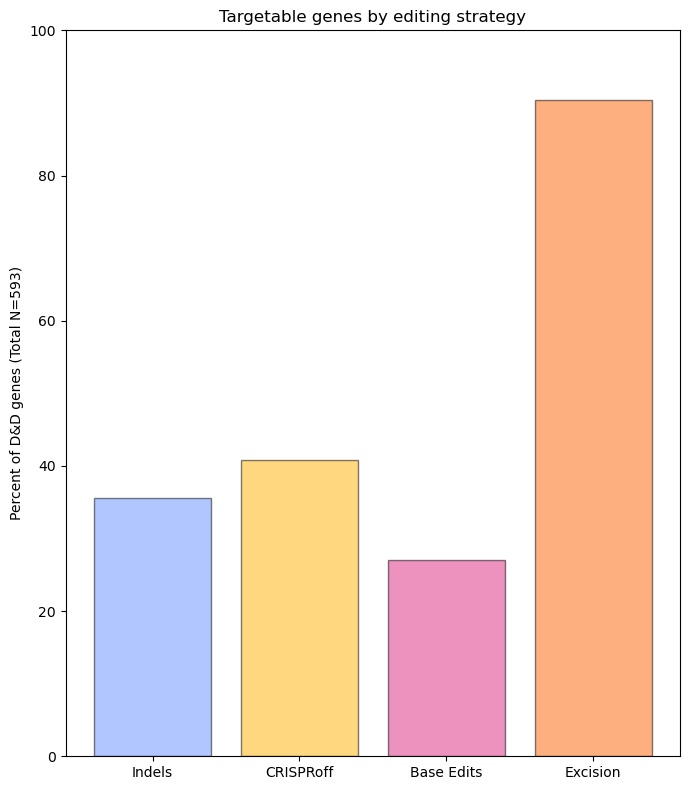

[35.58178752 40.80944351 26.98145025 90.38785835]


In [82]:
final_df = data[['hgnc_symbol', 'indel_targetable_post_NMD_assessment','crisproff_targetable','base_editable','excision_targetable']]
final_df = final_df.copy()
final_df.rename(columns={'indel_targetable_post_NMD_assessment':'indel_targetable'},inplace=True)

# plot the lower left bar plot separately
methods = [
    "indel_targetable",
    "crisproff_targetable",
    "base_editable",
    "excision_targetable"
]

counts = final_df[methods].sum()
labels = [
    "Indels",
    "CRISPRoff",
    "Base Edits",
    "Excision"
]
color_map=['#648FFF','#FFB000','#DC267F','#FE6100']
fig = plt.figure(figsize=(7, 8))
plt.bar(labels, (counts.values/len(final_df))*100, color=color_map, alpha=0.5, edgecolor="black")
plt.ylabel("Percent of D&D genes (Total N=593)")
plt.ylim((0,100))
plt.title("Targetable genes by editing strategy")
plt.tight_layout()
plt.show()

print((counts.values/len(final_df))*100)

In [86]:
im_df['num_excision_hets'].sum()

np.int64(0)

In [52]:
# os.path.join(results_dir, run_name, 'summary_files/dnd_593.csv')

'/wynton/home/capra/gramey02/ConklinCollab/data/dHS_and_related_GeneSets/pipeline_results/RUN_12_19_25/summary_files/dnd_593.csv'